# Modeling the result of a radio astronomy observation

This notebook uses the Julia package `RadioMdl.jl` to model the resulting power
levels seen by a radio telescope - the Westford antenna - when observing an
astronomical object such as Cas A.

In [1]:
using Dates
using DimensionalData
using DSP
using FFTW
using PyPlot
const plt = PyPlot
using Statistics

using Revise
using RadioMdl

## Define the instrument used to observe
---


### The antenna

The first step to define the instrument of observation is to define the antenna
used. The package has a custom structure `Antenna` that takes as inputs the size
of the antenna, a `DataFrame` structure with columns `:caz`, `:pol` and
`:gains`, containing the gain values and their angle coordinates
($\alpha$,$\beta$), the estimated radiation and aperture efficiency, the
frequency band where the model of antenna defined is valid and the potential
antenna physical temperature. $\alpha\in[0,360[$ and $\beta\in[0,180]$ are
defined as co-azimuth and polar angles, such that when the antenna is pointing
at the horizon, $\alpha=0$ gives a vertical slice of the pattern, with $\beta$ oriented towards the ground.

Multiple antenna models are already coded:
- a constant gain pattern
- following ITU-R RA.1631
- following ITU-R SA.509-3

The details are located in the `antenna_patern.jl` file.

A path to a `.cut` file (generated by TICRA) defining the power pattern model
can also be given in place of the `DataFrame` structure to load and format the gain
pattern.

In [2]:
# Size of antenna in m
ant_diameter = 18.3

# aperture efficiency
eta_app = .7

# radiation efficiency
eta_rad = .99

# valid frequency band of gain pattern model in Hz
freq_band = (10e9, 12e9)

# telescope antenna physical temperature
T_phy = 300.0 # in K

# load telescope antenna
file_pattern_path = "supp/single_cut_res.cut"
tel_ant = Antenna(file_pattern_path, ant_diameter, eta_app, eta_rad, freq_band, 
                  T_phy)

┌ Warning: This function assumes TICRA generated files
└ @ RadioMdl /home/samthe/Documents/Codes/RadioMdl/src/io.jl:55


Antenna{Float64}:
diameter: 18.3
gain pattern: SphereMap{Float64}:
sample grid size: (64, 18001)
grid prms: regular
angles resolutions (degrees): (5.625, 0.01)

aperture efficiency: 0.7
radiation efficiency: 0.99
physical temperature: 300.0
valid frequency range: (1.0e10, 1.2e10)


The result is a `Antenna` storing the different information and an interpolated
version of the gain pattern.

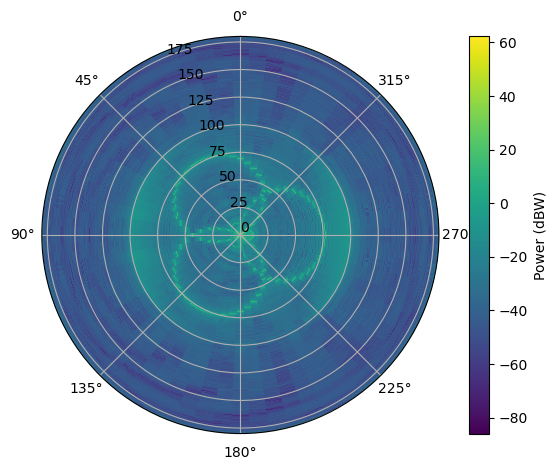

In [3]:
# plot gain pattern
alpha_grid = tel_ant.gain_pat.alpha_grid
beta_grid = tel_ant.gain_pat.beta_grid
smap = tel_ant.gain_pat.spheremap
fig, axs = plt.subplots(subplot_kw=Dict("projection"=>"polar"))
im = axs.pcolormesh(deg2rad.(alpha_grid), beta_grid, 10. .*log10.(smap'); cmap="viridis")
fig.colorbar(im, label="Power (dBW)")
axs.set_theta_zero_location("N")
fig.tight_layout()
display(gcf())

### The instrument

To define the `Instrument` of observation as a structure, we need an `Antenna`
structure, as well as a `Receiver`:

In [4]:
# freq resolution in Hz
freq_res = 2e6

# frequency of observation
cent_freq = 10.825e9 # in Hz

# bandwidth of telescope receiver
bw = 1024e6 # in Hz

# gain of amplifier chain
gain_amps = 10^(80/10)

# number of frequency channels to devide the bandwidth
freq_chan = Int(div(bw, freq_res))

# fequency channels
freq_bins = freq_range(freq_res, cent_freq, bw)

# telescope receiver temperature in K
adc_vpp = 1. # in Volts
adc_nb_bits = 16
T_adc = adc_noise_temperature(adc_vpp, adc_nb_bits, bw; instru_imp=50.)
T_LNA = 100. # in K
T_rx = friis_noise_temp((T_LNA, gain_amps), (T_adc, 1.)) # in K

# freq response
responsetype = Lowpass(bw/2-freq_res)
designmethod = FIRWindow(hamming(freq_chan+1)) # avoid 0 tap at beginning
filter_design = digitalfilter(responsetype, designmethod; fs=bw)
filter_design ./= sum(filter_design)
freq_resp = abs.(fftshift(fft(filter_design)))[1:end-1].^2

# create receiver
receiver = Receiver(freq_res, cent_freq, bw, gain_amps, T_rx, freq_resp)

Receiver{Float64}:
frequency resolution: 2.0e6
center frequency: 1.0825e10
bandwidth: 1.024e9
receiver temperature: 100.0000002744768
gain amplifiers: 1.0e8


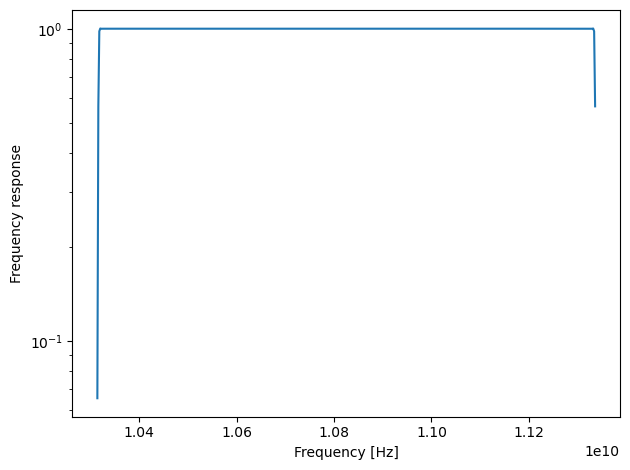

In [5]:
figure()
plt.plot(freq_range(receiver), receiver.freq_resp)
plt.yscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Frequency response")
plt.tight_layout()
display(gcf())

In [6]:
# coordinates of telescope
coords = Dict(:lat => 42.6129479883915, :lon => -71.49379366344017, 
              :alt => 86.7689687917009)

# create instrument
westford = Instrument(tel_ant, receiver, coords)

Instrument{Float64}:
antenna: Antenna{Float64}:
diameter: 18.3
gain pattern: SphereMap{Float64}:
sample grid size: (64, 18001)
grid prms: regular
angles resolutions (degrees): (5.625, 0.01)

aperture efficiency: 0.7
radiation efficiency: 0.99
physical temperature: 300.0
valid frequency range: (1.0e10, 1.2e10)

receiver: Receiver{Float64}:
frequency resolution: 2.0e6
center frequency: 1.0825e10
bandwidth: 1.024e9
receiver temperature: 100.0000002744768
gain amplifiers: 1.0e8

instrument at 42.6129479883915, -71.49379366344017, 86.7689687917009

## Define the observation plan
---

The next step is to define the observation plan and conditions.


### The pointing trajectory during the observation

It is possible to load an already computed table of pointing directions. For
instance, an `.arrow` file containing the position of Cas A over a window of
time. The package defines a `Trajectory` structure containing the position of
the antenna and the associated timestamps.

`Trajectory` can receive the path to an `.arrow`, `.csv` or `.dat` file instead of the
`DataFrame` to load an existing file. In that case, it is possible to give the
tags of the different columns if other names are present in the table to load.

In [7]:
# time window of generated source trajectory
dateformat = "yyyy-mm-dd\\THH:MM:SS.sss"
start_window = "2025-02-18T15:00:00.000"
stop_window = "2025-02-18T15:45:00.000"

# source position over time window
file_traj_obj_path = "supp/traj_files/casA_trajectory_Westford_$(start_window)_\
                      $(stop_window).arrow"
traj_src = Trajectory(file_traj_obj_path; time_tag = :time_stamps,
                      elevation_tag = :altitudes, azimuth_tag = :azimuths,
                      date_format = dateformat)

┌ Info: 'traj' must have coordinates defined in azimuth and elevation angles. The angles are converted in co-azimuth and polar angles as defined in ['SphereCoord'](@ref).
└ @ RadioMdl /home/samthe/Documents/Codes/RadioMdl/src/types.jl:165


Trajectory{Float64}:
number of time samples: 2701
time bounds: (DateTime("2025-02-18T15:00:00"), DateTime("2025-02-18T15:45:00"))
number of trajectory points per time sample: 1

Say the observation lasted 10min, with 5min offset and 5min on source:

In [8]:
# start-end of observation
start_obs = DateTime("2025-02-18T15:30:00.000", dateformat)
stop_obs = DateTime("2025-02-18T15:40:00.000", dateformat)

# offset from source at the beginning of the observation
offset_angles = SphereCoord(20., 0.) # (caz,pol) in degrees

# time of OFF-ON transition
time_off_src = start_obs
time_on_src = time_off_src + Minute(5)

# copy trajectory
traj_obs_1 = copy(traj_src)

# apply offset
offset_angle_trajectory!(traj_obs_1, offset_angles, time_off_src, time_on_src;
                         subtract_angles=true)


The package also allows to process multiple antenna position at the same time.
`Trajectory` stores in a `Matrix` the different position of the antenna, with
the first dimension following the timestamps defined in its `times` parameter
and the second dimension detailing the different position the simulator needs to
compute for, for each timestamps:

In [9]:
# add second trajectory
traj_obs_2 = copy(traj_src)
offset_angle_trajectory!(traj_obs_2, SphereCoord(20., 0.), start_obs, stop_obs)

# add third trajectory
traj_obs_3 = Trajectory(SphereCoord(45., 45.), traj_obs_1.times)
offset_angle_trajectory!(traj_obs_3, offset_angles, time_off_src, time_on_src)


# create the multiple trajectory
traj_obs = Trajectory(hcat(traj_obs_1.traj, traj_obs_2.traj, traj_obs_3.traj), 
                      traj_obs_1.times)

# create observation
observ = Observation(traj_obs, westford, start_obs, stop_obs)

Observation{Float64}:
antenna trajectory: Trajectory{Float64}:
number of time samples: 601
time bounds: (DateTime("2025-02-18T15:30:00"), DateTime("2025-02-18T15:40:00"))
number of trajectory points per time sample: 3
instrument: Instrument{Float64}:
antenna: Antenna{Float64}:
diameter: 18.3
gain pattern: SphereMap{Float64}:
sample grid size: (64, 18001)
grid prms: regular
angles resolutions (degrees): (5.625, 0.01)

aperture efficiency: 0.7
radiation efficiency: 0.99
physical temperature: 300.0
valid frequency range: (1.0e10, 1.2e10)

receiver: Receiver{Float64}:
frequency resolution: 2.0e6
center frequency: 1.0825e10
bandwidth: 1.024e9
receiver temperature: 100.0000002744768
gain amplifiers: 1.0e8

instrument at 42.6129479883915, -71.49379366344017, 86.7689687917009


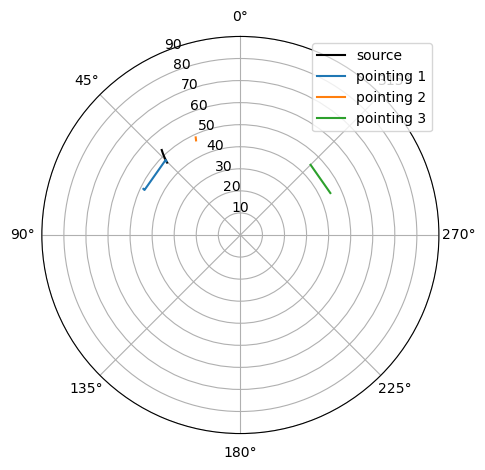

In [10]:
az_src = 360. .- [traj_src.traj[i].alpha for i in 1:size(traj_src.traj,1)]
pol_src = [traj_src.traj[i].beta for i in 1:size(traj_src.traj,1)]
fig, axs = plt.subplots(subplot_kw=Dict("projection"=>"polar"))
axs.plot(deg2rad.(az_src), pol_src, label="source", color="black")
for j in axes(observ.antenna_traj.traj,2)
    az_obs = 360. .- [observ.antenna_traj.traj[i,j].alpha
                      for i in axes(observ.antenna_traj.traj,1)]
    pol_obs = [observ.antenna_traj.traj[i,j].beta 
               for i in axes(observ.antenna_traj.traj,1)]
    axs.plot(deg2rad.(az_obs), pol_obs, label="pointing $j")
end
axs.legend()
axs.set_theta_zero_location("N")
axs.set_ylim(0., 90.)
fig.tight_layout()
display(gcf())

### Sky model

Accounting for the sky components is important to have a realistic simulation of
the power received. `RadioMdl.jl` models the sky as a spherical gridded map,
`SphereMap`, defined by co-azimuth and polar angles. When modeling the antenna
temperature, this sphere is then integrated over the full antenna pattern. The
`coord_frames.jl` file defines a sub-module that contains the methods to handle
the coordinates and coordinate frames used in the rest of the package.

The background can be define as a sky and ground portion:

In [11]:
# CMB temperature
T_CMB = 2.73 # in K

# galaxy temperature
T_gal = galactic_model(cent_freq) # in K

# background
T_bkg = T_CMB + T_gal

# ground temperature in K
T_gnd = ground_model([0.], collect(0.:1.:180.), 250.)

SphereMap{Float64}:
sample grid size: (2, 181)
grid prms: regular
angles resolutions (degrees): (180.0, 1.0)


The atmosphere is also important to account for:

In [12]:
# atmospheric temperature at zenith
T_atm_zenith = 273. # in K

# opacity of atmosphere at zenith
tau = .013

# atmospheric temperature model
T_bkg_atm = atmosphere_model(T_atm_zenith, tau, T_bkg)

SphereMap{Float64}:
sample grid size: (2, 181)
grid prms: regular
angles resolutions (degrees): (180.0, 1.0)


Adding up all of these sources gives:

In [13]:
# Total sky model in K
T_total_bkg = T_bkg_atm + T_gnd

SphereMap{Float64}:
sample grid size: (2, 181)
grid prms: regular
angles resolutions (degrees): (180.0, 1.0)


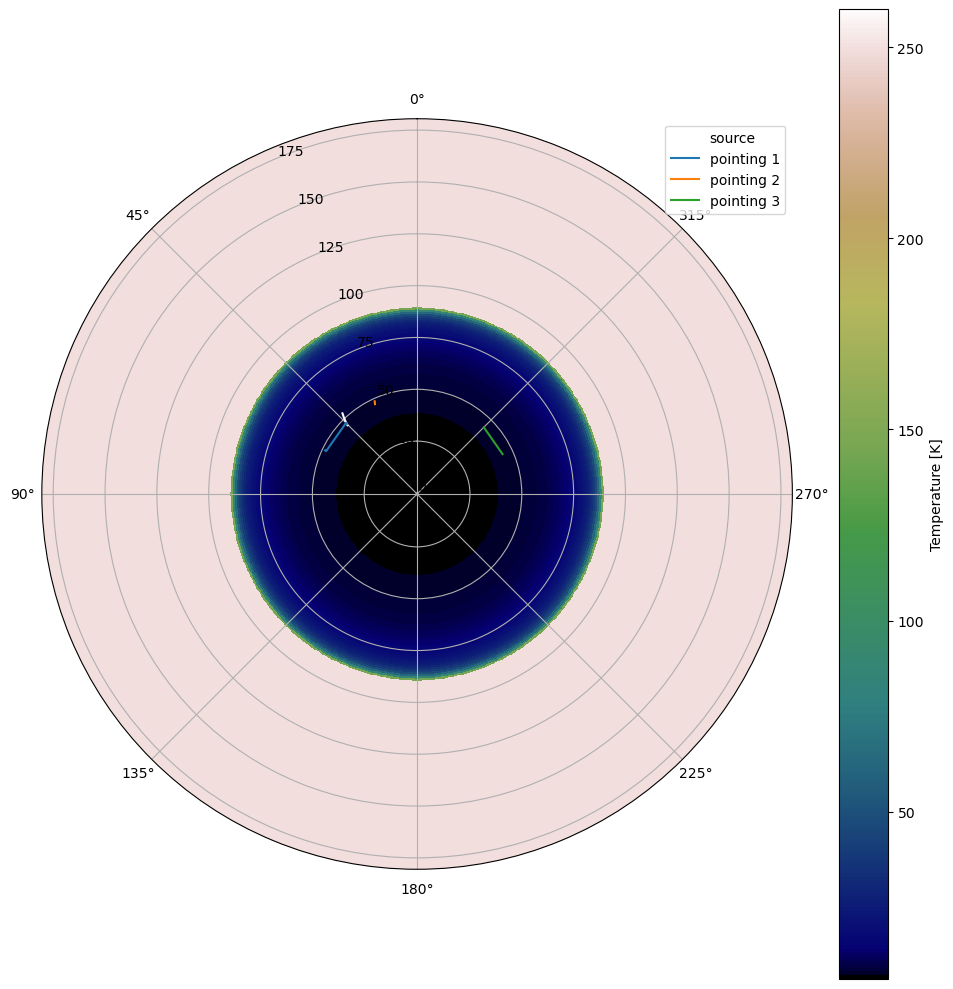

sys:1: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


In [14]:
# plot of sky model without source
alpha_sky_grid = collect(0.:1.:360.)
beta_sky_grid = T_total_bkg.beta_grid
smap = T_total_bkg.interp_map(alpha_sky_grid, beta_sky_grid)
az_src = 360. .- [traj_src.traj[i].alpha for i in 1:size(traj_src.traj,1)]
pol_src = [traj_src.traj[i].beta for i in 1:size(traj_src.traj,1)]
fig, axs = plt.subplots(subplot_kw=Dict("projection"=>"polar"), figsize=(10,10))
img = axs.pcolormesh(deg2rad.(alpha_sky_grid), beta_sky_grid, smap'; 
                     cmap="gist_earth", shading ="nearest", vmax=260.)
fig.colorbar(img, label="Temperature [K]")
axs.plot(deg2rad.(az_src), pol_src, label="source", color="white")
for j in axes(observ.antenna_traj.traj,2)
    az_obs = 360. .- [observ.antenna_traj.traj[i,j].alpha
                      for i in axes(observ.antenna_traj.traj,1)]
    pol_obs = [observ.antenna_traj.traj[i,j].beta 
               for i in axes(observ.antenna_traj.traj,1)]
    axs.plot(deg2rad.(az_obs), pol_obs, label="pointing $j")
end
axs.legend()
axs.set_theta_zero_location("N")
fig.tight_layout()
display(gcf())

Point-like sources are treated differently, as the math involved can be
simplified and talking about point-like source temperature makes little sense
usually. Given a flux and trajectory, we define Cassiopeia A as part of our sky
model:

In [15]:
# source flux in Jy
flux_src = estim_casA_flux.(freq_bins)

# source temperature through atmosphere
flux_atm_src = reduce(vcat, [atmos_opacity_impact(first.(flux_src), tau, t.beta)' 
                             for t in traj_src.traj])
F_src = PointLikeSrcFlux(TiFreqArray(flux_atm_src, traj_src.times, freq_bins), 
                         traj_src)

PointLikeSrcFlux{Float64}([341.3794611363506 341.33276009610654 … 319.39234222937927 319.3525412671353; 341.37980706226085 341.33310597469386 … 319.39266587534894 319.3528648727739; … ; 342.19611965005214 342.14930689013414 … 320.1564024766609 320.11650630132306; 342.1963824748549 342.1495696789822 … 320.1566483737897 320.1167521678095], Trajectory{Float64}:
number of time samples: 2701
time bounds: (DateTime("2025-02-18T15:00:00"), DateTime("2025-02-18T15:45:00"))
number of trajectory points per time sample: 1)

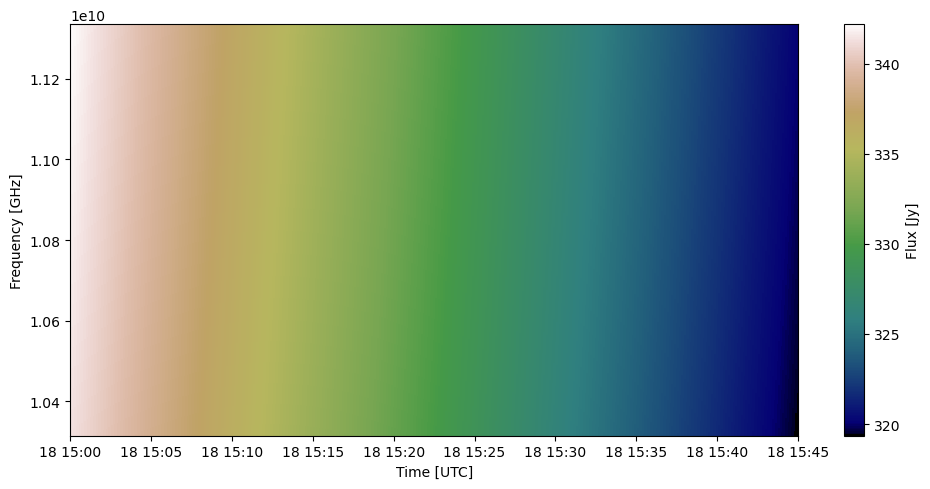

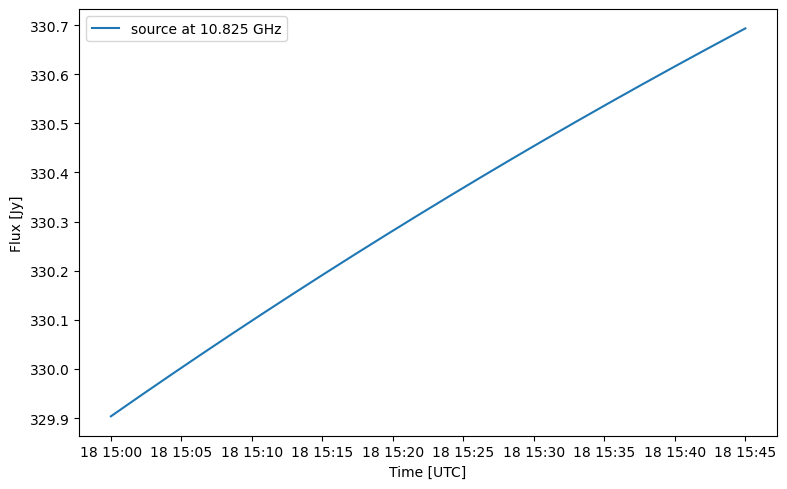

In [16]:
time_bins = F_src.traj.times
freq_bins = Array(dims(F_src.flux, :freqs))
fig, axs = plt.subplots(figsize=(10,5))
plot_extent = [time_bins[1], time_bins[end], freq_bins[1], freq_bins[end]]
img = axs.imshow(Array(F_src.flux), extent=plot_extent, aspect="auto", 
                 cmap="gist_earth", interpolation="none", origin="lower")
cbar = fig.colorbar(img)
cbar.set_label("Flux [Jy]")
axs.set_xlabel("Time [UTC]")
axs.set_ylabel("Frequency [GHz]")
fig.tight_layout()
display(gcf())

time_bins = F_src.traj.times
freq_bins = Array(dims(F_src.flux, :freqs))
fig, axs = plt.subplots(figsize=(8,5))
axs.plot(time_bins, Array(F_src.flux[freqs=Near(cent_freq)]), label="source at $(cent_freq/1e9) GHz")
axs.set_xlabel("Time [UTC]")
axs.set_ylabel("Flux [Jy]")
axs.legend()
fig.tight_layout()
display(gcf())

In [17]:
sky_mdl = SkyMdl(T_total_bkg, F_src)

SkyMdl{Float64}(SphereMap{Float64}:
sample grid size: (2, 181)
grid prms: regular
angles resolutions (degrees): (180.0, 1.0)
, PointLikeSrcFlux{Float64}[PointLikeSrcFlux{Float64}([341.3794611363506 341.33276009610654 … 319.39234222937927 319.3525412671353; 341.37980706226085 341.33310597469386 … 319.39266587534894 319.3528648727739; … ; 342.19611965005214 342.14930689013414 … 320.1564024766609 320.11650630132306; 342.1963824748549 342.1495696789822 … 320.1566483737897 320.1167521678095], Trajectory{Float64}:
number of time samples: 2701
time bounds: (DateTime("2025-02-18T15:00:00"), DateTime("2025-02-18T15:45:00"))
number of trajectory points per time sample: 1)])

## Satellite constellations
--- 
The package also defines a structure `Constellation` to account for aggregated
power from satellites.

### Antenna model

The first step is to define the antenna model for the type of satellites in the
constellation, as for instance the ITU recommended gain model via
`antenna_mdl_ITU_S_1528`. As in the following we will define their power
delivered as effective isotropically radiated power (EIRP), we choose here to
define a constant pattern and count on the fact that we are always looking at a
sidelobe from each satellites, that is, they avoid pointing directly at the
telescope.

If another model is chosen, pay attention to normalize the gain if you
parametrize satellites with EIRPs, as it is already accounted for.

In [18]:
# size of antenna in m
sat_ant_diameter = .8

# aperture efficiency
sat_eta_app = 1.

# radiation efficiency of telescope antenna
sat_eta_rad = 1.

# # maximum gain of satellite antenna
# sat_gain_max = 10^(38/10)

# valid frequency band
sat_freq_band = (10e9, 14e9)

# declination angles alpha
alphas = [0., 180., 359.]

# azimuth angles beta
betas = 0.:1.:180.

# create gain dataframe and normalize and put in EIRP
# sat_gain_pat = antenna_mdl_ITU_S_1528(sat_gain_max, sat_ant_diameter,
#                                       freq_to_wave(mean(sat_freq_band)), alphas, 
#                                       betas; sat_type="LEO")
# sat_gain_pat[:,:gains] ./= maximum(sat_gain_pat[:,:gains])
sat_gain_pat = antenna_mdl_cst(1., alphas, betas)

# satellite antenna physical temperature
sat_T_phy = 0. # in K

# create satellite antenna
sat_ant = Antenna(sat_ant_diameter, sat_gain_pat, sat_eta_app, sat_eta_rad, 
                  freq_band, sat_T_phy)


Antenna{Float64}:
diameter: 0.8
gain pattern: SphereMap{Float64}:
sample grid size: (3, 181)
grid prms: irregular (min, max)
angles resolutions (degrees): ((179.0, 180.0), (1.0, 1.0))

aperture efficiency: 1.0
radiation efficiency: 1.0
physical temperature: 0.0
valid frequency range: (1.0e10, 1.2e10)


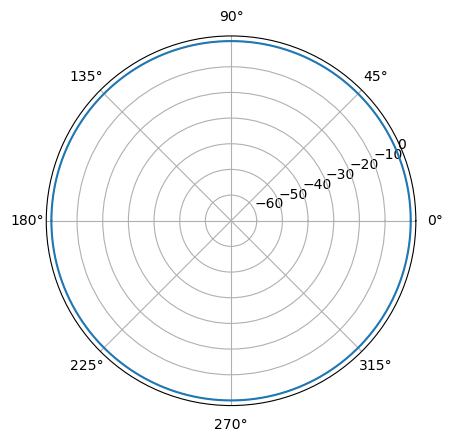

In [19]:
# plot gain pattern
beta_grid = sat_ant.gain_pat.beta_grid
fig, axs = plt.subplots(subplot_kw=Dict("projection"=>"polar"))
axs.plot(deg2rad.(beta_grid), 10 .*log10.(sat_ant.gain_pat.spheremap[1,:]),
         color="tab:blue")
axs.plot(-deg2rad.(beta_grid), 10 .*log10.(sat_ant.gain_pat.spheremap[end,:]),
         color="tab:blue")
axs.set_ylim(-70, 2)
display(gcf())

### Transmitter parameters

The satellites are transmitting information and can also be defined as an
`Instrument` structure, with a `Receiver` structure (note that this structure
should be renamed as `Transceiver` in future version):

In [20]:
# frequency of transmition
sat_freq = cent_freq # in Hz

# satellite transmition bandwidth
sat_bw = bw # in Hz

# number of frequency channels to devide the bandwidth
sat_freq_chan = Int(div(sat_bw, freq_res))

# gain of amplifier chain
sat_gain_amps = 1.

# satellite reciever temperature in K
sat_T_rx = 0. # in K

# satellite transmission model that depends on frequency
tmt_profile = ones(sat_freq_chan)
tmt_profile[div(sat_freq_chan, 2) .+ 
            (-div(sat_freq_chan, 20):div(sat_freq_chan, 20))] .= 1e-8
tmt_profile[div(sat_freq_chan, 2)] = 1.

# freq response
sat_responsetype = Lowpass(125e6-freq_res)
designmethod = FIRWindow(hamming(sat_freq_chan+1)) # avoid 0 tap at beginning
filter_design = digitalfilter(sat_responsetype, designmethod; fs=sat_bw)
freq_resp = abs.(fftshift(fft(filter_design)))[1:end-1].^2

freq_resp .*= tmt_profile
freq_resp ./= maximum(freq_resp)

# create transmitter of satellite
sat_receiver = Receiver(freq_res, sat_freq, sat_bw, sat_gain_amps, sat_T_rx, 
                        freq_resp)

# satellite effective isotropically radiated power to flux
max_EIRP_density = 10^(-60/10)

# create instrument
sat_instrument = Instrument(sat_ant, sat_receiver)

Instrument{Float64}:
antenna: Antenna{Float64}:
diameter: 0.8
gain pattern: SphereMap{Float64}:
sample grid size: (3, 181)
grid prms: irregular (min, max)
angles resolutions (degrees): ((179.0, 180.0), (1.0, 1.0))

aperture efficiency: 1.0
radiation efficiency: 1.0
physical temperature: 0.0
valid frequency range: (1.0e10, 1.2e10)

receiver: Receiver{Float64}:
frequency resolution: 2.0e6
center frequency: 1.0825e10
bandwidth: 1.024e9
receiver temperature: 0.0
gain amplifiers: 1.0

instrument coordinates not defined

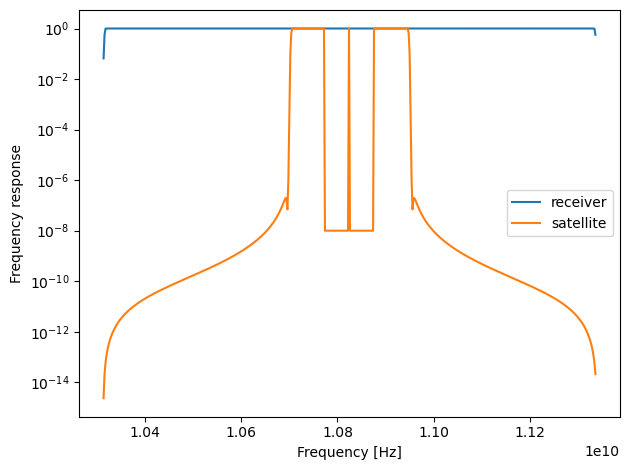

In [21]:
figure()
plt.plot(freq_range(receiver), receiver.freq_resp, label="receiver")
plt.plot(freq_range(sat_receiver), sat_receiver.freq_resp, label="satellite")
plt.yscale("log")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Frequency response")
plt.legend()
plt.tight_layout()
display(gcf())

Here we chose a frequnecy response that mimic a simplified downlink channel as
observed in some real experiments.

Note again that we normalized gains to define a `Satellite` structure that takes as
transmitted signal its effective isotropically radiated power (EIRP), already
containing gain effects.

### Constellation

A sub-module (in `satellite_position.jl`) can fetch satellites orbit information
and compute the trajectories over our instrument of a type of satellite (eg
Starlinks). It is also possible to point to a file storing precomputed
information for archive purposes or to limit access to online database.

From these trajectories, a list of `Satellite` structures is created
as a part of a `Constellation` structure. Seperating the two gives flexibility
in defining different satellite behaviors in the same constellation. 

This is particularly useful when wanting to simulate EPFD levels for testing
agreements with ITU threshold. In that case, each satellite can be defined as
taking a random value in a pool of possible EIRP values, thus giving a
statistical distribution over a Monte-Carlo run.

Note also that the `form_satellites_list` method accepts a `rotate_beam` boolean
keyword to randomly rotate the antenna pattern of each satellites, simulating
the beam forming done by the satellites.

In [22]:
# observation window
start_sat_window, stop_sat_window = start_obs, stop_obs

# fetch satellites orbit information
name_filters = ["STARLINK"]
avoid_names = ["[DTC]"]
sat_info_path = "supp/traj_files/Starlink_active.csv"
sats_catalog = fetch_satellites_info(; info_path=sat_info_path, 
                                     name_filters=name_filters, 
                                     avoid_names=avoid_names, save=false, verb=true)

# compute satellites positions
sat_time_res = Second(1)
min_elevation_filter = 5.
sats_pos = compute_sats_traj(sats_catalog, start_sat_window, stop_sat_window, 
                             westford.coords, sat_time_res; save=false, 
                             el_min=min_elevation_filter)

# create list of satellites
sats_list = form_satellites_list(sats_pos, sat_instrument, max_EIRP_density,
                                 start_sat_window, stop_sat_window; 
                                 rotate_beam=false,
                                 time_tag=:times, sat_id_tag=:sat, 
                                 elevation_tag=:elevations, azimuth_tag=:azimuths, 
                                 range_tag=:ranges);


## Constellation of Satellites
# satellite link budget estimator
lnk_bdgt(args...; kwds...) = classic_gain_link_budget(args...;
                                                      beam_avoid_angle=0.,
                                                      turn_off=false, kwds...)

# create constellation
starlink_constellation = Constellation("Starlink", sats_list, lnk_bdgt)

Found 6550 satellites with the given filters


Constellation{Float64}:
constellation name: Starlink
number of satellites: 482

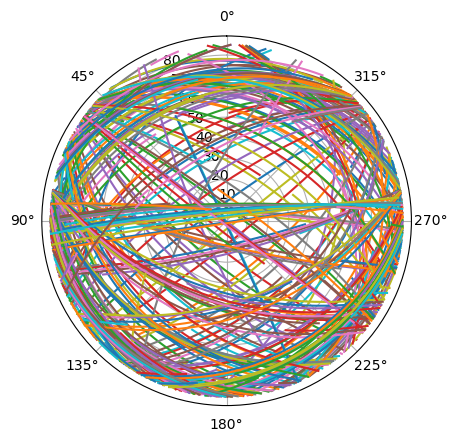

In [23]:
list_sats = get_sats_name(starlink_constellation)
sel_sats = 1:length(list_sats)
fig, ax = plt.subplots(subplot_kw=Dict("projection"=>"polar"))
for s in list_sats[sel_sats]
    sat_coords = get_coords(get_sat_traj(starlink_constellation, s))
    ax.plot(deg2rad.(360. .- sat_coords[1]), sat_coords[2])
end
ax.set_theta_zero_location("N")
display(gcf())

## Model total power received during observation
---

### Launch the simulation

The `model_observ_psd!` takes as input the `Observation` and can also take a
`sky_mdl` function and one or a vector of `Constellation`. 

In [24]:
model_observ_psd!(observ, sky_mdl, starlink_constellation)

┌ 601×512×3 DimArray{Float64, 3} ┐
├────────────────────────────────┴─────────────────────────────────────── dims ┐
  ↓ times Sampled{DateTime} [DateTime("2025-02-18T15:30:00"), …, DateTime("2025-02-18T15:40:00")] ForwardOrdered Irregular Points,
  → freqs Sampled{Float64} 1.0314e10:2.0e6:1.1336e10 ForwardOrdered Regular Points,
  ↗ traj_idx Sampled{Int64} 1:3 ForwardOrdered Regular Points
└──────────────────────────────────────────────────────────────────────────────┘
[:, :, 1]
 ↓ →                   1.0314e10    1.0316e10    …  1.1334e10    1.1336e10
  2025-02-18T15:30:00  1.0517e-14   9.05711e-14     1.57565e-13  9.05711e-14
  2025-02-18T15:30:01  1.0517e-14   9.05708e-14     1.57564e-13  9.05708e-14
  2025-02-18T15:30:02  1.0517e-14   9.05706e-14     1.57564e-13  9.05706e-14
 ⋮                                               ⋱               
  2025-02-18T15:39:57  1.17524e-14  1.01204e-13     1.71837e-13  9.87709e-14
  2025-02-18T15:39:58  1.17524e-14  1.01204e-13     1.71836e-13  9.

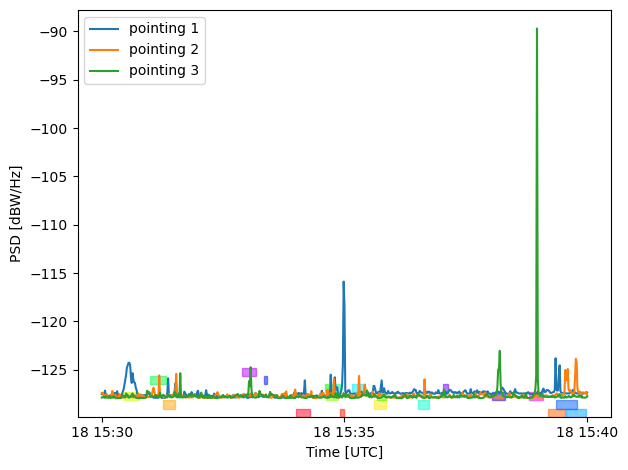

In [25]:
time_bins = observ.antenna_traj.times
fig, axs = plt.subplots()
for i in axes(observ.antenna_traj.traj, 2)
    axs.plot(time_bins, 10. .*log10.(observ.result[traj_idx=i,freqs=Near(10.9e9)]),
             label="pointing $i")
end
axs.set_xlabel("Time [UTC]")
axs.set_ylabel("PSD [dBW/Hz]")
axs.legend()
fig.tight_layout()

# plot close-by satellites passes
sats_close = RadioMdl.SatPos.sats_close_to_pointing(sats_pos, 
                                                    observ.antenna_traj.times,
                                                    observ.antenna_traj.traj)

row_end_times = DateTime[]
cmap = plt.get_cmap("gist_rainbow")
for i in axes(sats_close, 1)
    sat = sats_close[i,:sat]
    min_pass, max_pass = sats_close[i,:t_start], sats_close[i,:t_stop]
    row = findfirst(t -> t <= min_pass, row_end_times)
    if row === nothing
        push!(row_end_times, max_pass)
        row = length(row_end_times)
    else
        row_end_times[row] = max_pass
    end
    ymin = (row - 1) * 0.02
    ymax = ymin + 0.02
    cur_color = cmap((i - 1) / size(sats_close, 1))
    axs.axvspan(min_pass, max_pass, alpha=.5, ymin=ymin, ymax=ymax, color=cur_color,
                label=sats_close[i,:sat])
end
display(gcf())

### Comparing with other simulations

The link budget method also have a keyword `beam_avoid_angle` that takes an
angle value. If the angle between the boresight of a satellite and the telescope
pointing direction is below this angle, the satellite "steers" away. Note that
in our case, the satellite have a constant gain pattern and so stearing away
will not change the PSD values. As the EIRP levels being set to sidelobe levels,
a more valid strategy would be to turn off the satellite when passing close to
the antenna pointing direction. The method accepts a `turn_off` keyword for that strategy:

In [26]:
obs_beam_avoid = Observation(traj_obs, westford, start_obs, stop_obs)

lnk_bdgt_beam_avoid(args...; 
                    kwds...) = classic_gain_link_budget(args...; 
                                                        beam_avoid_angle = 20.,
                                                        turn_off = true, kwds...)
starlink_const_beam_avoid = Constellation("Starlink", sats_list, 
                                          lnk_bdgt_beam_avoid)
model_observ_psd!(obs_beam_avoid, sky_mdl, starlink_const_beam_avoid);

Without a satellite constellation:

In [27]:
obs_src = Observation(traj_obs, westford, start_obs, stop_obs)
model_observ_psd!(obs_src, sky_mdl);

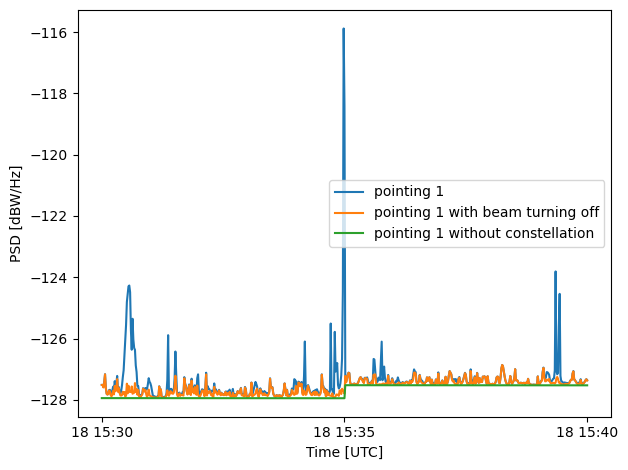

In [28]:
time_bins = observ.antenna_traj.times
fig, axs = plt.subplots()
i = 1
axs.plot(time_bins, 10. .*log10.(observ.result[traj_idx=i,freqs=Near(10.9e9)]),
         label="pointing $i")
axs.plot(time_bins, 10. .*log10.(obs_beam_avoid.result[traj_idx=i,
                                                       freqs=Near(10.9e9)]),
         label="pointing $i with beam turning off")
axs.plot(time_bins, 10. .*log10.(obs_src.result[traj_idx=i,freqs=Near(10.9e9)]),
         label="pointing $i without constellation")
axs.set_xlabel("Time [UTC]")
axs.set_ylabel("PSD [dBW/Hz]")
axs.legend()
fig.tight_layout()
display(gcf())

### Focusing on a specific timestamp

Focusing on a specific time to see where the satellites are located compare to
the pointing direction of the telescope:

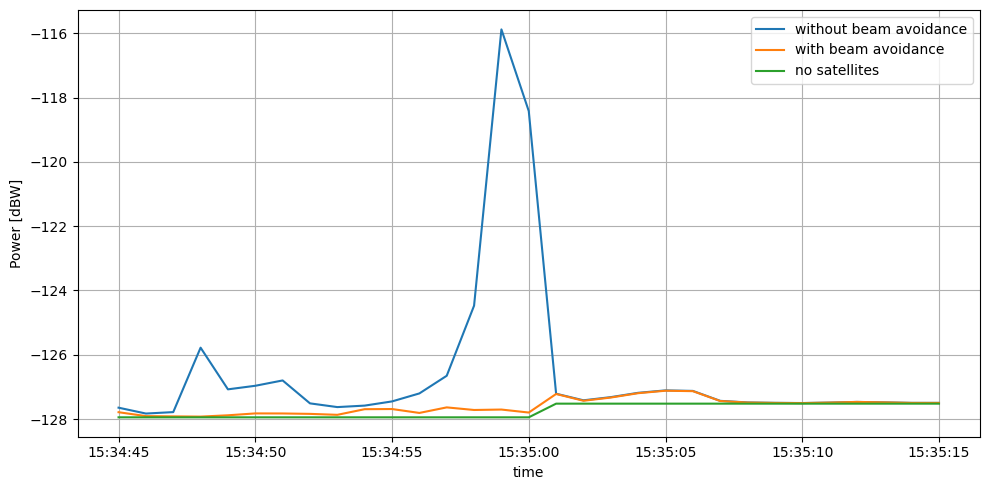

In [29]:
# zoom dates
start_zoom = DateTime("2025-02-18T15:34:45.000", dateformat)
stop_zoom = DateTime("2025-02-18T15:35:15.000", dateformat)
time_samples = observ.antenna_traj.times
time_zoom = findall(start_zoom .<= time_samples .<= stop_zoom)

fig, axs = plt.subplots(figsize=(10, 5))
# Observation without beam avoidance
plot_result = observ.result[traj_idx=1,freqs=Near(10.9e9)][time_zoom,1,1]
axs.plot(time_samples[time_zoom], 10 .*log10.(plot_result), label="without beam avoidance")
# Observation with beam avoidance
plot_result = obs_beam_avoid.result[traj_idx=1,freqs=Near(10.9e9)][time_zoom,1,1]
axs.plot(time_samples[time_zoom], 10 .*log10.(plot_result), label="with beam avoidance")
# # Observation without constellation
plot_result = obs_src.result[traj_idx=1,freqs=Near(10.9e9)][time_zoom,1,1]
axs.plot(time_samples[time_zoom], 10 .*log10.(plot_result), label="no satellites")
axs.legend()
axs.set_xlabel("time")
axs.set_ylabel("Power [dBW]")
axs.grid(true)
axs.legend()
fig.tight_layout()
display(gcf())

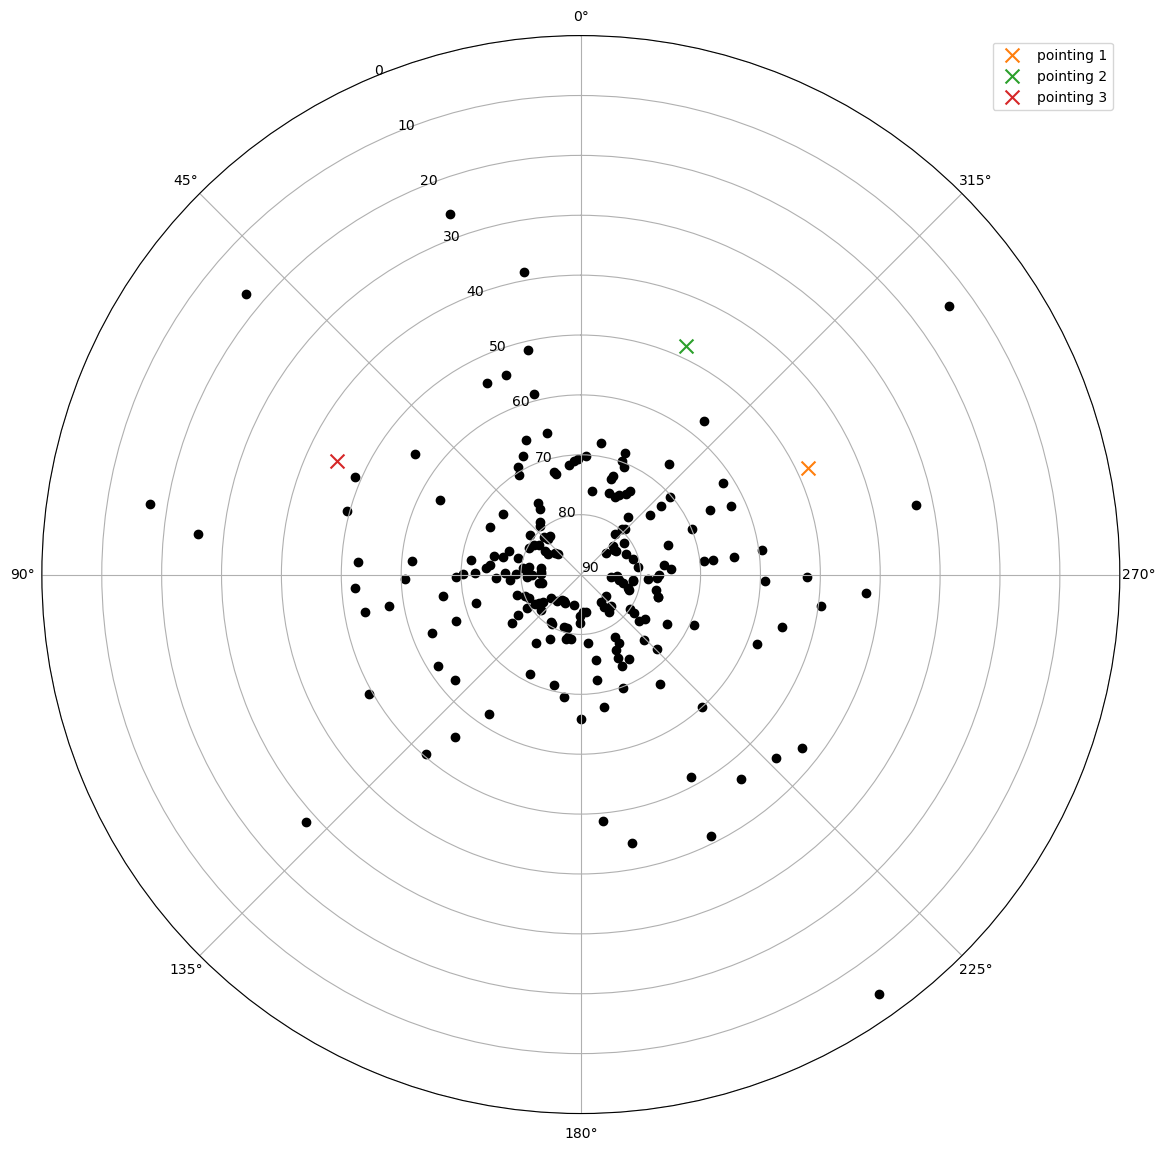

In [30]:
time_study = DateTime("2025-02-18T15:34:59.000", dateformat)
sats_at_t = get_sats_names_at_time(starlink_constellation, time_study)

sel_sats = 1:length(sats_at_t)
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(1, 1, 1, polar=true)
for s in sats_at_t[sel_sats]
    sat = get_sat_traj(starlink_constellation, s)
    sat_pt = sat.traj[sat.times .== time_study][1]
    ax.scatter(deg2rad.(mod.(360. .- sat_pt.alpha, 360.)), 90 .- sat_pt.beta, color="black")
end
instru_pt = observ.antenna_traj.traj[observ.antenna_traj.times .== time_study,:][1,:]
for i in eachindex(instru_pt)
    p = instru_pt[i]
    ax.scatter(deg2rad.(mod.(p.alpha, 360.)), 90 .- p.beta, marker="x", c="C$(i)", 
               label="pointing $i", s=1e2)
end
ax.set_yticks(0:10:90, string.(Vector(90:-10:0)))
ax.legend()
ax.set_theta_zero_location("N")
display(gcf())

## Model total power over entire sky
---

The package also allows modeling the power received at each time samples for
multiple positions over the sky. `sky_grid` is a method defining an
almost-regular grid of cells over the sky, following the ITU-R S.1586.

In [31]:
# sky grid
sky_grid_cells = sky_grid(90)

Row,pol_min,pol_max,caz_min,caz_max
,Float64,Float64,Float64,Float64
1,0.0,1.0,0.0,120.0
2,0.0,1.0,120.0,240.0
3,0.0,1.0,240.0,360.0
4,1.0,2.0,0.0,40.0
5,1.0,2.0,40.0,80.0
6,1.0,2.0,80.0,120.0
7,1.0,2.0,120.0,160.0
8,1.0,2.0,160.0,200.0
9,1.0,2.0,200.0,240.0


It is possible to define a `Trajectory` that points at the full sky over each
time samples:

In [32]:
# transform in trajectory
time_samples = observ.antenna_traj.times
sky_grid_cells.pol = (sky_grid_cells.pol_min .+ sky_grid_cells.pol_max) ./ 2
sky_grid_cells.caz = (sky_grid_cells.caz_min .+ sky_grid_cells.caz_max) ./ 2
traj = [SphereCoord(r.caz, r.pol) for r in eachrow(sky_grid_cells)]
ant_map = Trajectory([traj[j] for i in 1:length(time_samples), j in eachindex(traj)], 
                     time_samples)

Trajectory{Float64}:
number of time samples: 601
time bounds: (DateTime("2025-02-18T15:30:00"), DateTime("2025-02-18T15:40:00"))
number of trajectory points per time sample: 20582

Then the observation follows the same framework:

In [33]:
# observation over full sky
time_plot = DateTime("2025-02-18T15:34:58.000", dateformat)
observ_sky =  Observation(ant_map, westford, time_plot - Second(5), time_plot + Second(5))

Observation{Float64}:
antenna trajectory: Trajectory{Float64}:
number of time samples: 11
time bounds: (DateTime("2025-02-18T15:34:53"), DateTime("2025-02-18T15:35:03"))
number of trajectory points per time sample: 20582
instrument: Instrument{Float64}:
antenna: Antenna{Float64}:
diameter: 18.3
gain pattern: SphereMap{Float64}:
sample grid size: (64, 18001)
grid prms: regular
angles resolutions (degrees): (5.625, 0.01)

aperture efficiency: 0.7
radiation efficiency: 0.99
physical temperature: 300.0
valid frequency range: (1.0e10, 1.2e10)

receiver: Receiver{Float64}:
frequency resolution: 2.0e6
center frequency: 1.0825e10
bandwidth: 1.024e9
receiver temperature: 100.0000002744768
gain amplifiers: 1.0e8

instrument at 42.6129479883915, -71.49379366344017, 86.7689687917009


Creating a new list of satellites where each one is beam-forming in a random direction:

In [34]:
sats_list_beamform = form_satellites_list(sats_pos, sat_instrument, max_EIRP_density,
                                          start_sat_window, stop_sat_window; 
                                          rotate_beam=true,
                                          time_tag=:times, sat_id_tag=:sat, 
                                          elevation_tag=:elevations, azimuth_tag=:azimuths, 
                                          range_tag=:ranges)

starlink_constellation = Constellation("Starlink", sats_list_beamform, lnk_bdgt)

Constellation{Float64}:
constellation name: Starlink
number of satellites: 482

The simulation gives:

In [35]:
model_observ_psd!(observ_sky, nothing, starlink_constellation)

┌ 11×512×20582 DimArray{Float64, 3} ┐
├───────────────────────────────────┴──────────────────────────────────── dims ┐
  ↓ times Sampled{DateTime} [DateTime("2025-02-18T15:34:53"), …, DateTime("2025-02-18T15:35:03")] ForwardOrdered Irregular Points,
  → freqs Sampled{Float64} 1.0314e10:2.0e6:1.1336e10 ForwardOrdered Regular Points,
  ↗ traj_idx Sampled{Int64} 1:20582 ForwardOrdered Regular Points
└──────────────────────────────────────────────────────────────────────────────┘
[:, :, 1]
 ↓ →                   1.0314e10    1.0316e10   …  1.1334e10    1.1336e10
  2025-02-18T15:34:53  9.31228e-15  8.0196e-14     1.39515e-13  8.0196e-14
  2025-02-18T15:34:54  9.31228e-15  8.0196e-14     1.39515e-13  8.0196e-14
  2025-02-18T15:34:55  9.31228e-15  8.0196e-14     1.39515e-13  8.0196e-14
 ⋮                                              ⋱               
  2025-02-18T15:35:00  9.31228e-15  8.0196e-14     1.39515e-13  8.0196e-14
  2025-02-18T15:35:01  9.31228e-15  8.0196e-14     1.39515e-13  8.0196

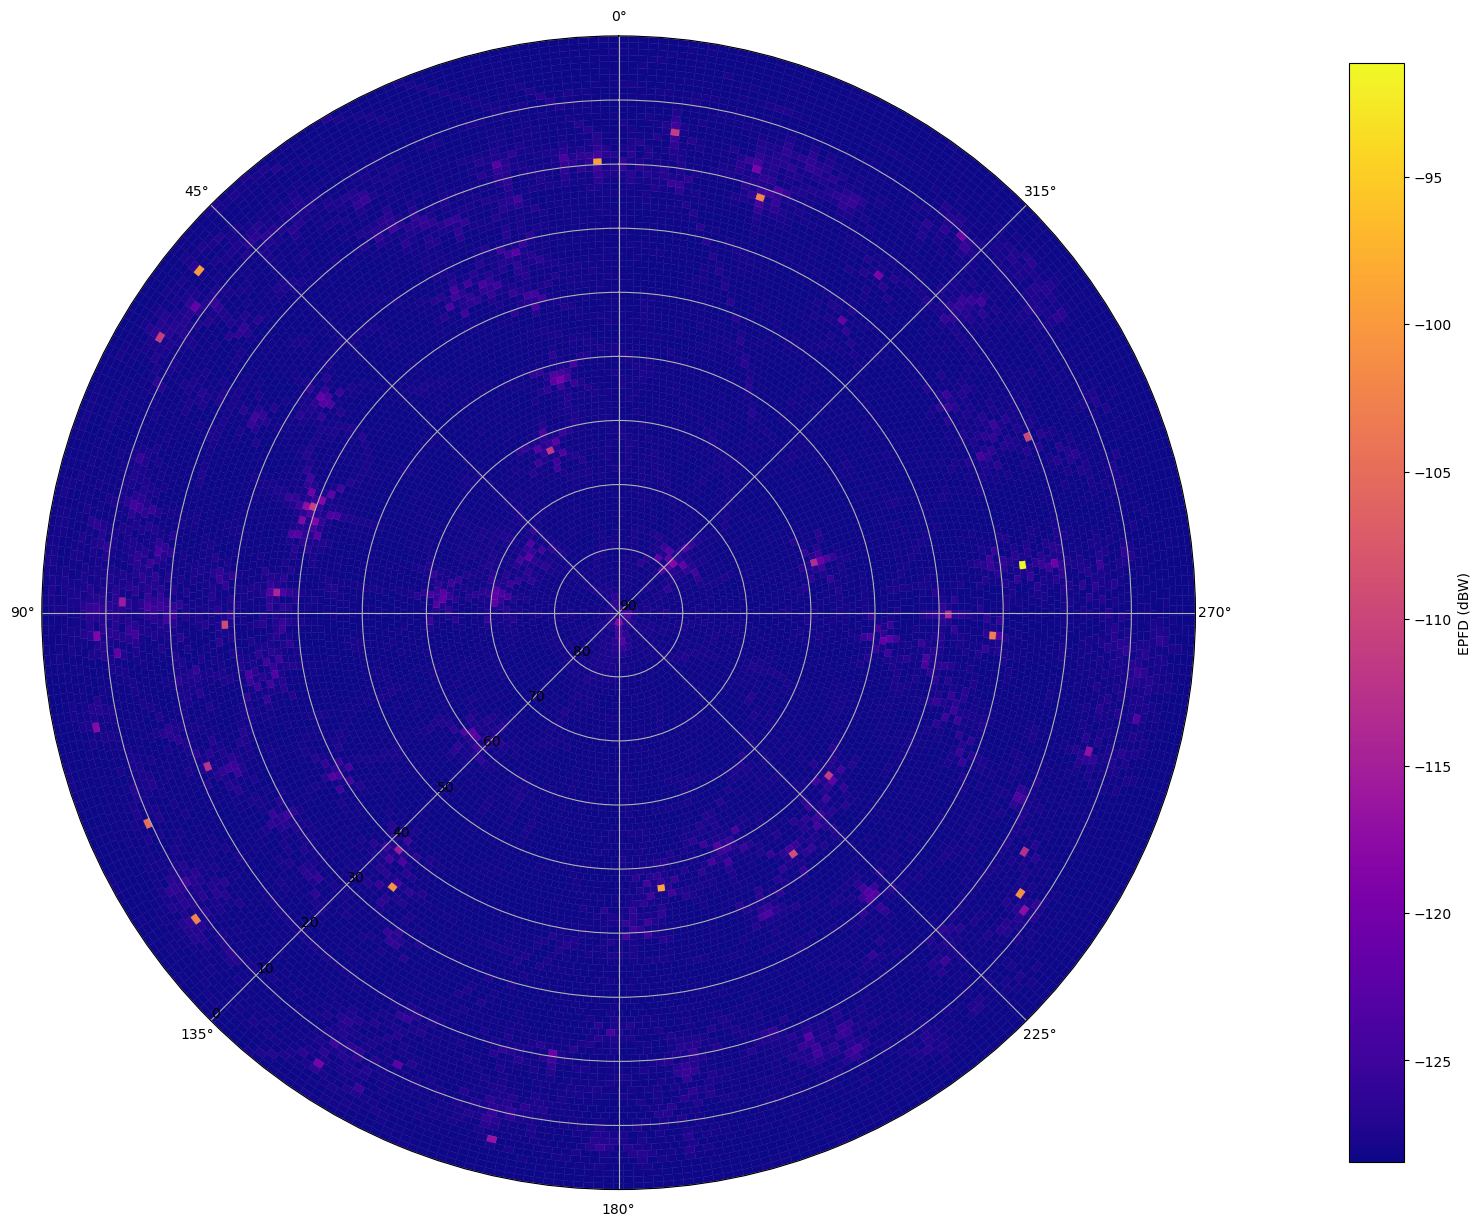

In [36]:
psd_dB = 10 .* log10.(observ_sky.result[times=end,freqs=Near(10.9e9)])
vmin, vmax = extrema(psd_dB)

cmap = get_cmap("plasma")
norm = plt.matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
colors = [cmap(norm(v)) for v in psd_dB]

centers = deg2rad.(360. .- sky_grid_cells[:,:caz])
widths  = deg2rad.(sky_grid_cells[:,:caz_max] .- sky_grid_cells[:,:caz_min])
heights = sky_grid_cells[:,:pol_max] .- sky_grid_cells[:,:pol_min]
bottoms = sky_grid_cells[:,:pol_min]

fig = figure(figsize=(16,16))
ax = fig.add_subplot(111, polar=true)
ax.bar(centers, heights; width=widths, bottom=bottoms, color=colors,
       edgecolor=colors, linewidth=0.3, align="center");
ax.set_theta_zero_location("N")
ax.set_theta_direction(1)
ax.set_rlabel_position(135)
ax.set_ylim(0., 90.)
ax.set_yticks(0:10:90, string.(Vector(90:-10:0)))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="EPFD (dBW)", shrink=0.7, pad=0.1)
tight_layout()
display(gcf())